In [1]:
# Import libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression, LogisticRegression
from sklearn.metrics import mean_absolute_error, r2_score, accuracy_score

# Settings
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (12, 6)
pd.set_option('display.max_columns', 50)

print("✅ Libraries loaded!")

# Load beneficiary data (patient demographics)
print("\n📊 Loading Beneficiary Data...")
beneficiary = pd.read_csv('data/DE1_0_2010_Beneficiary_Summary_File_Sample_2.csv')

print(f"✅ Beneficiary data loaded!")
print(f"   Total beneficiaries: {len(beneficiary):,}")
print(f"   Columns: {len(beneficiary.columns)}")

# Preview
print("\n🔍 First 5 beneficiaries:")
beneficiary.head()

✅ Libraries loaded!

📊 Loading Beneficiary Data...
✅ Beneficiary data loaded!
   Total beneficiaries: 112,845
   Columns: 32

🔍 First 5 beneficiaries:


,DESYNPUF_ID,BENE_BIRTH_DT,BENE_DEATH_DT,BENE_SEX_IDENT_CD,BENE_RACE_CD,BENE_ESRD_IND,SP_STATE_CODE,BENE_COUNTY_CD,BENE_HI_CVRAGE_TOT_MONS,BENE_SMI_CVRAGE_TOT_MONS,BENE_HMO_CVRAGE_TOT_MONS,PLAN_CVRG_MOS_NUM,SP_ALZHDMTA,SP_CHF,SP_CHRNKIDN,SP_CNCR,SP_COPD,SP_DEPRESSN,SP_DIABETES,SP_ISCHMCHT,SP_OSTEOPRS,SP_RA_OA,SP_STRKETIA,MEDREIMB_IP,BENRES_IP,PPPYMT_IP,MEDREIMB_OP,BENRES_OP,PPPYMT_OP,MEDREIMB_CAR,BENRES_CAR,PPPYMT_CAR
0,00000B48BCF4AD29,19230901,NaN,2,5,Y,10,260,12,12,0,12,2,1,2,2,2,2,1,1,2,2,2,0.0,0.0,0.0,600.0,30.0,0.0,3800.0,1460.0,0.0
1,0000525AB30E4DEF,19201001,NaN,2,1,0,31,300,12,12,0,12,2,2,2,2,2,2,1,2,2,2,2,0.0,0.0,0.0,240.0,190.0,0.0,440.0,60.0,0.0
2,00009C897C3D8372,19320101,NaN,1,1,0,7,70,12,12,12,12,2,1,2,2,2,2,1,2,1,2,2,0.0,0.0,0.0,210.0,160.0,0.0,580.0,250.0,0.0
3,0001168CE43BE51B,19340901,NaN,2,1,0,6,200,12,0,0,0,2,2,2,2,2,2,2,2,2,2,2,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4,0002E494BC87CE10,19140701,NaN,1,2,0,5,200,12,12,0,0,2,2,2,2,2,2,2,2,2,2,2,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


In [2]:
# Load inpatient claims (hospital admissions)
print("📊 Loading Inpatient Claims...")
inpatient = pd.read_csv('data/DE1_0_2008_to_2010_Inpatient_Claims_Sample_2.csv')

print(f"✅ Inpatient claims loaded!")
print(f"   Total claims: {len(inpatient):,}")
print(f"   Columns: {len(inpatient.columns)}")

# Preview
print("\n🔍 First 5 inpatient claims:")
inpatient.head()

📊 Loading Inpatient Claims...
✅ Inpatient claims loaded!
   Total claims: 66,494
   Columns: 81

🔍 First 5 inpatient claims:


,DESYNPUF_ID,CLM_ID,SEGMENT,CLM_FROM_DT,CLM_THRU_DT,PRVDR_NUM,CLM_PMT_AMT,NCH_PRMRY_PYR_CLM_PD_AMT,AT_PHYSN_NPI,OP_PHYSN_NPI,OT_PHYSN_NPI,CLM_ADMSN_DT,ADMTNG_ICD9_DGNS_CD,CLM_PASS_THRU_PER_DIEM_AMT,NCH_BENE_IP_DDCTBL_AMT,NCH_BENE_PTA_COINSRNC_LBLTY_AM,NCH_BENE_BLOOD_DDCTBL_LBLTY_AM,CLM_UTLZTN_DAY_CNT,NCH_BENE_DSCHRG_DT,CLM_DRG_CD,ICD9_DGNS_CD_1,ICD9_DGNS_CD_2,ICD9_DGNS_CD_3,ICD9_DGNS_CD_4,ICD9_DGNS_CD_5,...,HCPCS_CD_21,HCPCS_CD_22,HCPCS_CD_23,HCPCS_CD_24,HCPCS_CD_25,HCPCS_CD_26,HCPCS_CD_27,HCPCS_CD_28,HCPCS_CD_29,HCPCS_CD_30,HCPCS_CD_31,HCPCS_CD_32,HCPCS_CD_33,HCPCS_CD_34,HCPCS_CD_35,HCPCS_CD_36,HCPCS_CD_37,HCPCS_CD_38,HCPCS_CD_39,HCPCS_CD_40,HCPCS_CD_41,HCPCS_CD_42,HCPCS_CD_43,HCPCS_CD_44,HCPCS_CD_45
0,00000B48BCF4AD29,45461150060934,1,20080707.0,20080718.0,1000GD,57000.0,0.0,1.219278e+09,7.451661e+09,NaN,20080707,4280,0.0,1024.0,0.0,0.0,11.0,20080718,281,4241,2760,7802,2763,42821,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,00000B48BCF4AD29,45541150055035,1,20080724.0,20080726.0,1030RD,0.0,0.0,9.812675e+09,NaN,9.812675e+09,20080724,4280,0.0,1024.0,0.0,0.0,2.0,20080726,296,42823,2859,5119,56400,4263,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,00000B48BCF4AD29,45731150068478,1,20080805.0,20080820.0,1001NA,24000.0,0.0,6.035410e+09,9.404475e+09,NaN,20080805,78609,0.0,1024.0,0.0,0.0,15.0,20080820,263,3970,2800,9971,41410,V4581,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,0000525AB30E4DEF,45811150057351,1,20080525.0,20080605.0,3900MB,4000.0,0.0,1.511429e+09,7.340276e+09,NaN,20080525,5609,60.0,1024.0,0.0,0.0,11.0,20080605,349,5609,42732,V4579,V4501,79902,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,0000525AB30E4DEF,45391150058019,1,20080918.0,20080924.0,3100JN,8000.0,0.0,3.198318e+09,9.156656e+09,NaN,20080918,78906,100.0,1024.0,0.0,0.0,6.0,20080924,388,5579,V4611,5849,99591,42731,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [3]:
# Load outpatient claims (office visits, procedures, ER)
print("📊 Loading Outpatient Claims...")
outpatient = pd.read_csv('data/DE1_0_2008_to_2010_Outpatient_Claims_Sample_2.csv')

print(f"✅ Outpatient claims loaded!")
print(f"   Total claims: {len(outpatient):,}")
print(f"   Columns: {len(outpatient.columns)}")

# Preview
print("\n🔍 First 5 outpatient claims:")
outpatient.head()

📊 Loading Outpatient Claims...


/var/folders/n6/_vcfrx_n5hddhlg7v0725lfw0000gn/T/ipykernel_78329/4189576059.py:3: DtypeWarning: Columns (21,23,24,25,26,27) have mixed types. Specify dtype option on import or set low_memory=False.
  outpatient = pd.read_csv('data/DE1_0_2008_to_2010_Outpatient_Claims_Sample_2.csv')


✅ Outpatient claims loaded!
   Total claims: 792,562
   Columns: 76

🔍 First 5 outpatient claims:


,DESYNPUF_ID,CLM_ID,SEGMENT,CLM_FROM_DT,CLM_THRU_DT,PRVDR_NUM,CLM_PMT_AMT,NCH_PRMRY_PYR_CLM_PD_AMT,AT_PHYSN_NPI,OP_PHYSN_NPI,OT_PHYSN_NPI,NCH_BENE_BLOOD_DDCTBL_LBLTY_AM,ICD9_DGNS_CD_1,ICD9_DGNS_CD_2,ICD9_DGNS_CD_3,ICD9_DGNS_CD_4,ICD9_DGNS_CD_5,ICD9_DGNS_CD_6,ICD9_DGNS_CD_7,ICD9_DGNS_CD_8,ICD9_DGNS_CD_9,ICD9_DGNS_CD_10,ICD9_PRCDR_CD_1,ICD9_PRCDR_CD_2,ICD9_PRCDR_CD_3,...,HCPCS_CD_21,HCPCS_CD_22,HCPCS_CD_23,HCPCS_CD_24,HCPCS_CD_25,HCPCS_CD_26,HCPCS_CD_27,HCPCS_CD_28,HCPCS_CD_29,HCPCS_CD_30,HCPCS_CD_31,HCPCS_CD_32,HCPCS_CD_33,HCPCS_CD_34,HCPCS_CD_35,HCPCS_CD_36,HCPCS_CD_37,HCPCS_CD_38,HCPCS_CD_39,HCPCS_CD_40,HCPCS_CD_41,HCPCS_CD_42,HCPCS_CD_43,HCPCS_CD_44,HCPCS_CD_45
0,00000B48BCF4AD29,391362254696220,1,20080315.0,20080315.0,10026U,70.0,0.0,2.296430e+09,NaN,NaN,0.0,2721,V1250,2330,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,00000B48BCF4AD29,391612254357344,1,20080405.0,20080405.0,0300YM,50.0,0.0,5.824171e+09,NaN,NaN,0.0,72999,72981,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,00000B48BCF4AD29,391812254100253,1,20080604.0,20080621.0,1002GD,300.0,0.0,6.317513e+08,NaN,NaN,0.0,7216,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,97140,97110,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,00000B48BCF4AD29,391012254328356,1,20081024.0,20081024.0,1000GD,1100.0,0.0,7.611013e+09,7.611013e+09,NaN,0.0,99671,4019,V1046,53081,V5861,3441,2859,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,00000B48BCF4AD29,391602254471197,1,20090414.0,20090414.0,1000UU,60.0,0.0,7.190756e+09,NaN,NaN,0.0,7916,V7644,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [4]:
# Let's check for data quality issues (REAL data is always messy!)
print("🔍 DATA QUALITY ASSESSMENT")
print("="*70)

print("\n📊 INPATIENT CLAIMS ISSUES:")
print(f"Total inpatient claims: {len(inpatient):,}")
print(f"Missing values per column:")
print(inpatient.isnull().sum()[inpatient.isnull().sum() > 0].head(10))

print(f"\n💰 Claims with $0 payment:")
zero_payment = (inpatient['CLM_PMT_AMT'] == 0).sum()
print(f"   {zero_payment:,} claims ({zero_payment/len(inpatient)*100:.1f}%)")

print(f"\n📅 Claims with missing dates:")
missing_dates = inpatient['CLM_FROM_DT'].isnull().sum()
print(f"   {missing_dates:,} claims")

print(f"\n🏥 Claims with missing diagnosis codes:")
missing_dx = inpatient['ICD9_DGNS_CD_1'].isnull().sum()
print(f"   {missing_dx:,} claims ({missing_dx/len(inpatient)*100:.1f}%)")

print("\n" + "="*70)
print("📊 BENEFICIARY DATA ISSUES:")
print(f"Total beneficiaries: {len(beneficiary):,}")
print(f"Missing chronic condition indicators:")
chronic_cols = ['SP_ALZHDMTA', 'SP_CHF', 'SP_CHRNKIDN', 'SP_CNCR', 
                'SP_COPD', 'SP_DEPRESSN', 'SP_DIABETES', 'SP_ISCHMT']
for col in chronic_cols[:4]:  # Check first 4
    missing = beneficiary[col].isnull().sum()
    if missing > 0:
        print(f"   {col}: {missing:,} missing")

print("\n✅ Data quality assessment complete!")
print("Next: We'll clean this data before analysis")

🔍 DATA QUALITY ASSESSMENT

📊 INPATIENT CLAIMS ISSUES:
Total inpatient claims: 66,494
Missing values per column:
CLM_FROM_DT                  60
CLM_THRU_DT                  60
AT_PHYSN_NPI                672
OP_PHYSN_NPI              27721
OT_PHYSN_NPI              58761
ADMTNG_ICD9_DGNS_CD         597
NCH_BENE_IP_DDCTBL_AMT     2220
CLM_UTLZTN_DAY_CNT           60
ICD9_DGNS_CD_1               90
ICD9_DGNS_CD_2              519
dtype: int64

💰 Claims with $0 payment:
   1,980 claims (3.0%)

📅 Claims with missing dates:
   60 claims

🏥 Claims with missing diagnosis codes:
   90 claims (0.1%)

📊 BENEFICIARY DATA ISSUES:
Total beneficiaries: 112,845
Missing chronic condition indicators:

✅ Data quality assessment complete!
Next: We'll clean this data before analysis


In [5]:
# DATA CLEANING
print("🧹 CLEANING DATA...")
print("="*70)

# Store original counts
original_inpatient = len(inpatient)
original_beneficiary = len(beneficiary)

print("\n📊 STEP 1: Clean Inpatient Claims")
print(f"   Starting with: {original_inpatient:,} claims")

# Remove claims with $0 payment (can't analyze cost drivers with $0!)
print("\n   Removing $0 payment claims...")
inpatient_clean = inpatient[inpatient['CLM_PMT_AMT'] > 0].copy()
removed_zero = original_inpatient - len(inpatient_clean)
print(f"   ✓ Removed {removed_zero:,} claims with $0 payment")

# Remove claims with missing dates
print("\n   Removing claims with missing dates...")
inpatient_clean = inpatient_clean[inpatient_clean['CLM_FROM_DT'].notna()].copy()
removed_dates = len(inpatient) - len(inpatient_clean) - removed_zero
print(f"   ✓ Removed {removed_dates:,} claims with missing dates")

# Remove claims with missing primary diagnosis
print("\n   Removing claims with missing diagnosis codes...")
before = len(inpatient_clean)
inpatient_clean = inpatient_clean[inpatient_clean['ICD9_DGNS_CD_1'].notna()].copy()
removed_dx = before - len(inpatient_clean)
print(f"   ✓ Removed {removed_dx:,} claims with missing diagnosis")

print(f"\n   Final inpatient claims: {len(inpatient_clean):,}")
print(f"   Total removed: {original_inpatient - len(inpatient_clean):,} ({(original_inpatient - len(inpatient_clean))/original_inpatient*100:.1f}%)")

print("\n" + "="*70)
print("📊 STEP 2: Merge with Beneficiary Data")

# Only keep beneficiaries who have claims (inner join)
print(f"   Starting beneficiaries: {len(beneficiary):,}")
print(f"   Merging with clean claims...")

# Get unique beneficiary IDs from claims
beneficiaries_with_claims = inpatient_clean['DESYNPUF_ID'].unique()
print(f"   Beneficiaries with inpatient claims: {len(beneficiaries_with_claims):,}")

# Keep only beneficiaries who have claims
beneficiary_clean = beneficiary[beneficiary['DESYNPUF_ID'].isin(beneficiaries_with_claims)].copy()
print(f"   Final beneficiaries: {len(beneficiary_clean):,}")

print("\n" + "="*70)
print("✅ DATA CLEANING COMPLETE!")
print("\n📊 FINAL CLEAN DATASET:")
print(f"   Beneficiaries: {len(beneficiary_clean):,}")
print(f"   Inpatient Claims: {len(inpatient_clean):,}")
print(f"   Outpatient Claims: {len(outpatient):,} (not cleaned yet)")

print("\n💡 CLEANING DECISIONS MADE:")
print("   1. Excluded $0 claims - can't analyze costs without cost data")
print("   2. Excluded missing dates - needed for time-based analysis")
print("   3. Excluded missing diagnosis - can't identify conditions without DX codes")
print("   4. Kept only beneficiaries with claims - analyzing utilization patterns")
print("\n   This is realistic! Real-world data always needs cleaning.")

🧹 CLEANING DATA...

📊 STEP 1: Clean Inpatient Claims
   Starting with: 66,494 claims

   Removing $0 payment claims...
   ✓ Removed 2,038 claims with $0 payment

   Removing claims with missing dates...
   ✓ Removed 59 claims with missing dates

   Removing claims with missing diagnosis codes...
   ✓ Removed 18 claims with missing diagnosis

   Final inpatient claims: 64,379
   Total removed: 2,115 (3.2%)

📊 STEP 2: Merge with Beneficiary Data
   Starting beneficiaries: 112,845
   Merging with clean claims...
   Beneficiaries with inpatient claims: 36,981
   Final beneficiaries: 36,552

✅ DATA CLEANING COMPLETE!

📊 FINAL CLEAN DATASET:
   Beneficiaries: 36,552
   Inpatient Claims: 64,379
   Outpatient Claims: 792,562 (not cleaned yet)

💡 CLEANING DECISIONS MADE:
   1. Excluded $0 claims - can't analyze costs without cost data
   2. Excluded missing dates - needed for time-based analysis
   3. Excluded missing diagnosis - can't identify conditions without DX codes
   4. Kept only benefi

💰 INPATIENT CLAIM COST ANALYSIS

📊 CLAIM COST STATISTICS:
Total claims: 64,379
Total paid: $632,284,530.00
Average claim: $9,821.29
Median claim: $7,000.00
Min claim: $10.00
Max claim: $57,000.00

📈 COST DISTRIBUTION:
count    64379.000000
mean      9821.285357
std       9160.055321
min         10.000000
25%       4000.000000
50%       7000.000000
75%      11000.000000
max      57000.000000
Name: CLM_PMT_AMT, dtype: float64


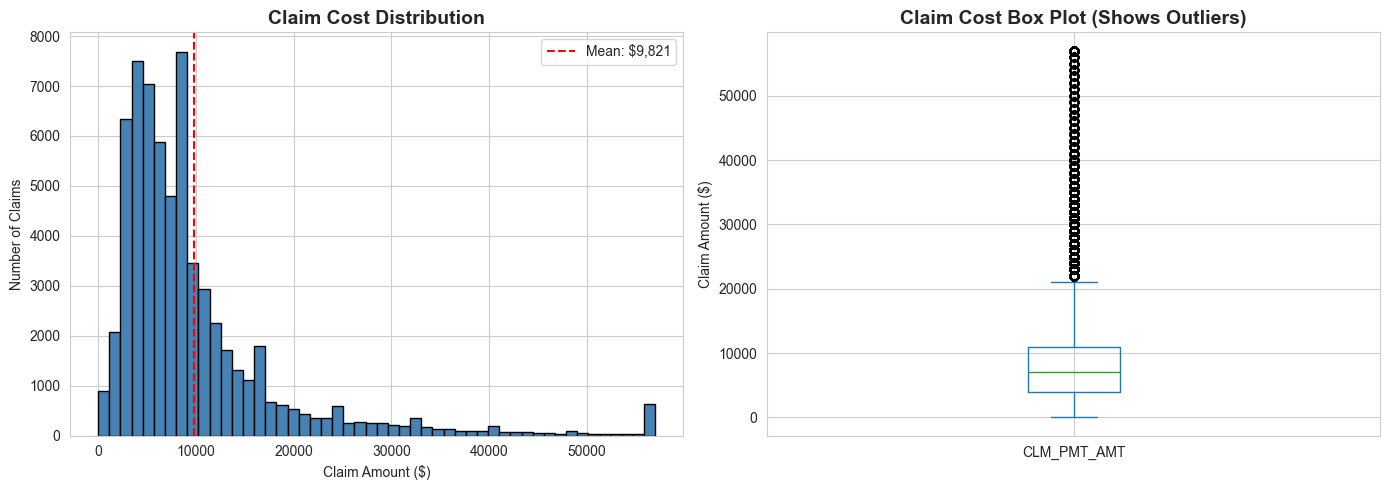


✅ Chart saved: claim_cost_distribution.png


In [8]:
# COST ANALYSIS
print("💰 INPATIENT CLAIM COST ANALYSIS")
print("="*70)

# Basic statistics
print("\n📊 CLAIM COST STATISTICS:")
print(f"Total claims: {len(inpatient_clean):,}")
print(f"Total paid: ${inpatient_clean['CLM_PMT_AMT'].sum():,.2f}")
print(f"Average claim: ${inpatient_clean['CLM_PMT_AMT'].mean():,.2f}")
print(f"Median claim: ${inpatient_clean['CLM_PMT_AMT'].median():,.2f}")
print(f"Min claim: ${inpatient_clean['CLM_PMT_AMT'].min():,.2f}")
print(f"Max claim: ${inpatient_clean['CLM_PMT_AMT'].max():,.2f}")

# Distribution
print("\n📈 COST DISTRIBUTION:")
print(inpatient_clean['CLM_PMT_AMT'].describe())

# Visualize
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Histogram
inpatient_clean['CLM_PMT_AMT'].hist(bins=50, ax=axes[0], color='steelblue', edgecolor='black')
axes[0].set_title('Claim Cost Distribution', fontsize=14, fontweight='bold')
axes[0].set_xlabel('Claim Amount ($)')
axes[0].set_ylabel('Number of Claims')
axes[0].axvline(inpatient_clean['CLM_PMT_AMT'].mean(), color='red', linestyle='--', label=f"Mean: ${inpatient_clean['CLM_PMT_AMT'].mean():,.0f}")
axes[0].legend()

# Box plot
inpatient_clean['CLM_PMT_AMT'].plot(kind='box', ax=axes[1], vert=True)
axes[1].set_title('Claim Cost Box Plot (Shows Outliers)', fontsize=14, fontweight='bold')
axes[1].set_ylabel('Claim Amount ($)')

plt.tight_layout()
plt.savefig('claim_cost_distribution.png', dpi=300, bbox_inches='tight')
plt.show()

print("\n✅ Chart saved: claim_cost_distribution.png")

In [9]:
# OUTPATIENT DATA - BRIEF ASSESSMENT
print("🏥 OUTPATIENT CLAIMS - BRIEF REVIEW")
print("="*70)

print(f"\n📊 Dataset Overview:")
print(f"   Total outpatient claims: {len(outpatient):,}")
print(f"   Unique beneficiaries: {outpatient['DESYNPUF_ID'].nunique():,}")
print(f"   Average claim amount: ${outpatient['CLM_PMT_AMT'].mean():,.2f}")

print(f"\n💡 Decision:")
print(f"   Focusing analysis on INPATIENT claims for this project because:")
print(f"   • Inpatient avg: ${inpatient_clean['CLM_PMT_AMT'].mean():,.2f} vs Outpatient avg: ${outpatient['CLM_PMT_AMT'].mean():,.2f}")
print(f"   • Inpatient claims are {inpatient_clean['CLM_PMT_AMT'].mean() / outpatient['CLM_PMT_AMT'].mean():.1f}x more expensive")
print(f"   • Better for identifying high-cost members (project goal)")
print(f"   • Clearer signal for risk segmentation")

print(f"\n📈 Combined Dataset Available:")
print(f"   • Inpatient: {len(inpatient_clean):,} claims")
print(f"   • Outpatient: {len(outpatient):,} claims")  
print(f"   • TOTAL: {len(inpatient_clean) + len(outpatient):,} claims across dataset")

print(f"\n✅ Proceeding with inpatient-focused analysis")
print(f"   (Outpatient data available for future analysis if needed)")

🏥 OUTPATIENT CLAIMS - BRIEF REVIEW

📊 Dataset Overview:
   Total outpatient claims: 792,562
   Unique beneficiaries: 85,295
   Average claim amount: $284.50

💡 Decision:
   Focusing analysis on INPATIENT claims for this project because:
   • Inpatient avg: $9,821.29 vs Outpatient avg: $284.50
   • Inpatient claims are 34.5x more expensive
   • Better for identifying high-cost members (project goal)
   • Clearer signal for risk segmentation

📈 Combined Dataset Available:
   • Inpatient: 64,379 claims
   • Outpatient: 792,562 claims
   • TOTAL: 856,941 claims across dataset

✅ Proceeding with inpatient-focused analysis
   (Outpatient data available for future analysis if needed)


In [11]:
# MEMBER-LEVEL COST ANALYSIS
print("👥 MEMBER-LEVEL COST AGGREGATION")
print("="*70)

# Aggregate claims by member
member_costs = inpatient_clean.groupby('DESYNPUF_ID').agg({
    'CLM_PMT_AMT': ['sum', 'mean', 'count'],
    'CLM_ID': 'count'
}).reset_index()

# Flatten column names
member_costs.columns = ['member_id', 'total_cost', 'avg_cost_per_claim', 'claim_count', 'claim_count2']
member_costs = member_costs.drop('claim_count2', axis=1)

print(f"\n📊 MEMBER STATISTICS:")
print(f"Total unique members with inpatient claims: {len(member_costs):,}")
print(f"Average cost per member: ${member_costs['total_cost'].mean():,.2f}")
print(f"Median cost per member: ${member_costs['total_cost'].median():,.2f}")
print(f"Max cost (single member): ${member_costs['total_cost'].max():,.2f}")

print(f"\n🏥 UTILIZATION PATTERNS:")
print(f"Average claims per member: {member_costs['claim_count'].mean():.1f}")
print(f"Median claims per member: {member_costs['claim_count'].median():.0f}")
print(f"Max claims (one member): {member_costs['claim_count'].max():.0f}")

# Distribution of claims per member
print(f"\n📈 MEMBER DISTRIBUTION BY # OF CLAIMS:")
one_claim = (member_costs['claim_count'] == 1).sum()
two_three = ((member_costs['claim_count'] >= 2) & (member_costs['claim_count'] <= 3)).sum()
four_plus = (member_costs['claim_count'] >= 4).sum()

print(f"   1 claim: {one_claim:,} members ({one_claim/len(member_costs)*100:.1f}%)")
print(f"   2-3 claims: {two_three:,} members ({two_three/len(member_costs)*100:.1f}%)")
print(f"   4+ claims: {four_plus:,} members ({four_plus/len(member_costs)*100:.1f}%)")

# Show top 10 most expensive members
print(f"\n💰 TOP 10 HIGHEST-COST MEMBERS:")
print(member_costs.nlargest(10, 'total_cost')[['member_id', 'total_cost', 'claim_count']])

print("\n✅ Member-level costs calculated!")
print(f"   Ready for risk segmentation...")

👥 MEMBER-LEVEL COST AGGREGATION

📊 MEMBER STATISTICS:
Total unique members with inpatient claims: 36,981
Average cost per member: $17,097.55
Median cost per member: $11,000.00
Max cost (single member): $264,000.00

🏥 UTILIZATION PATTERNS:
Average claims per member: 1.7
Median claims per member: 1
Max claims (one member): 14

📈 MEMBER DISTRIBUTION BY # OF CLAIMS:
   1 claim: 22,508 members (60.9%)
   2-3 claims: 11,243 members (30.4%)
   4+ claims: 3,230 members (8.7%)

💰 TOP 10 HIGHEST-COST MEMBERS:
              member_id  total_cost  claim_count
16965  7448915DB9524076    264000.0           12
8945   3DA0CF9290F3E99E    251000.0            6
18909  8191AB4DDEC7DDD0    215000.0            7
8333   3985A0746A4B0662    193000.0            6
29480  CB65CCCCD1A4E6ED    193000.0            7
3545   1917D75FA533EB76    185000.0           11
31872  DC9AE64B08D64ED3    181000.0            6
31962  DD4418634F26CB54    178000.0            7
17979  7B0CFA5EECC257CB    175000.0           14
26807

🎯 MEMBER RISK SEGMENTATION

📊 RISK THRESHOLDS:
   Low Risk: < $18,000
   Medium Risk: $18,000 - $39,000
   High Risk: > $39,000

📈 RISK SEGMENTATION RESULTS:
               member_count  total_cost_sum  avg_cost_per_member  avg_claims
risk_category                                                               
High Risk              3814     228177730.0             59826.36        3.74
Low Risk              25558     208651090.0              8163.83        1.26
Medium Risk            7609     195455710.0             25687.44        2.36

💰 COST DISTRIBUTION BY RISK CATEGORY:

Low Risk:
   Members: 25,558 (69.1%)
   Total Cost: $208,651,090.00 (33.0%)
   Avg per member: $8,163.83

Medium Risk:
   Members: 7,609 (20.6%)
   Total Cost: $195,455,710.00 (30.9%)
   Avg per member: $25,687.44

High Risk:
   Members: 3,814 (10.3%)
   Total Cost: $228,177,730.00 (36.1%)
   Avg per member: $59,826.36

🚨 KEY FINDING (FOR YOUR RESUME!):
   Top 10% of members drive 36.1% of total costs!
   This equ

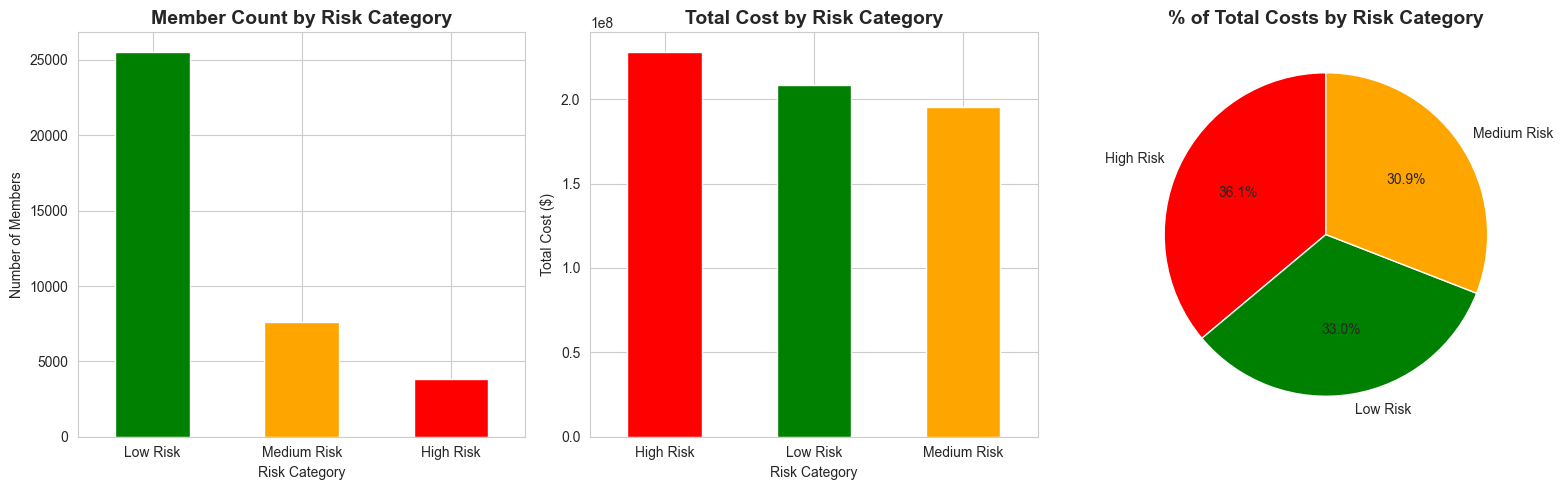


✅ Chart saved: risk_segmentation.png
✅ Risk segmentation complete!


In [12]:
# MEMBER RISK SEGMENTATION
print("🎯 MEMBER RISK SEGMENTATION")
print("="*70)

# Create risk categories based on total cost
# Using percentiles: Bottom 70% = Low, 70-90% = Medium, Top 10% = High
percentile_70 = member_costs['total_cost'].quantile(0.70)
percentile_90 = member_costs['total_cost'].quantile(0.90)

print(f"\n📊 RISK THRESHOLDS:")
print(f"   Low Risk: < ${percentile_70:,.0f}")
print(f"   Medium Risk: ${percentile_70:,.0f} - ${percentile_90:,.0f}")
print(f"   High Risk: > ${percentile_90:,.0f}")

# Assign risk categories
def assign_risk(cost):
    if cost < percentile_70:
        return 'Low Risk'
    elif cost < percentile_90:
        return 'Medium Risk'
    else:
        return 'High Risk'

member_costs['risk_category'] = member_costs['total_cost'].apply(assign_risk)

# Analysis by risk category
risk_summary = member_costs.groupby('risk_category').agg({
    'member_id': 'count',
    'total_cost': ['sum', 'mean'],
    'claim_count': 'mean'
}).round(2)

risk_summary.columns = ['member_count', 'total_cost_sum', 'avg_cost_per_member', 'avg_claims']

print(f"\n📈 RISK SEGMENTATION RESULTS:")
print(risk_summary)

# Calculate percentage of total costs
total_all_costs = member_costs['total_cost'].sum()
print(f"\n💰 COST DISTRIBUTION BY RISK CATEGORY:")
for risk in ['Low Risk', 'Medium Risk', 'High Risk']:
    risk_data = member_costs[member_costs['risk_category'] == risk]
    pct_members = len(risk_data) / len(member_costs) * 100
    pct_costs = risk_data['total_cost'].sum() / total_all_costs * 100
    print(f"\n{risk}:")
    print(f"   Members: {len(risk_data):,} ({pct_members:.1f}%)")
    print(f"   Total Cost: ${risk_data['total_cost'].sum():,.2f} ({pct_costs:.1f}%)")
    print(f"   Avg per member: ${risk_data['total_cost'].mean():,.2f}")

# KEY INSIGHT: Top 10% analysis
high_risk = member_costs[member_costs['risk_category'] == 'High Risk']
high_risk_pct_members = len(high_risk) / len(member_costs) * 100
high_risk_pct_costs = high_risk['total_cost'].sum() / total_all_costs * 100

print(f"\n🚨 KEY FINDING (FOR YOUR RESUME!):")
print(f"   Top {high_risk_pct_members:.0f}% of members drive {high_risk_pct_costs:.1f}% of total costs!")
print(f"   This equals ${high_risk['total_cost'].sum():,.2f} in high-cost member spending")

# Visualize
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

# Chart 1: Member count by risk
risk_counts = member_costs['risk_category'].value_counts()
colors = {'Low Risk': 'green', 'Medium Risk': 'orange', 'High Risk': 'red'}
risk_counts.plot(kind='bar', ax=axes[0], color=[colors[x] for x in risk_counts.index])
axes[0].set_title('Member Count by Risk Category', fontsize=14, fontweight='bold')
axes[0].set_ylabel('Number of Members')
axes[0].set_xlabel('Risk Category')
axes[0].tick_params(axis='x', rotation=0)

# Chart 2: Total cost by risk
risk_costs = member_costs.groupby('risk_category')['total_cost'].sum()
risk_costs.plot(kind='bar', ax=axes[1], color=[colors[x] for x in risk_costs.index])
axes[1].set_title('Total Cost by Risk Category', fontsize=14, fontweight='bold')
axes[1].set_ylabel('Total Cost ($)')
axes[1].set_xlabel('Risk Category')
axes[1].tick_params(axis='x', rotation=0)

# Chart 3: Cost distribution (pie chart)
axes[2].pie(risk_costs, labels=risk_costs.index, autopct='%1.1f%%', 
            colors=[colors[x] for x in risk_costs.index], startangle=90)
axes[2].set_title('% of Total Costs by Risk Category', fontsize=14, fontweight='bold')

plt.tight_layout()
plt.savefig('risk_segmentation.png', dpi=300, bbox_inches='tight')
plt.show()

print("\n✅ Chart saved: risk_segmentation.png")
print("✅ Risk segmentation complete!")

🏥 TOP COST-DRIVING DIAGNOSES

📊 ANALYZING PRIMARY DIAGNOSIS CODES...

💰 TOP 10 DIAGNOSES BY TOTAL COST:
     diagnosis_code  total_cost      avg_cost  claim_count
2682          V5789  28000100.0  16213.144181         1727
971           41401  24892170.0  15814.593393         1574
43             0389  24520700.0  15183.095975         1615
1241            486  17533430.0   7110.068938         2466
959           41071  14808100.0  13139.396628         1127
1297          51881  14391200.0  17614.687882          817
1833          71536  13010500.0  11903.476670         1093
1026           4280  11788840.0   8164.016620         1444
1249          49121   9769000.0   6351.755527         1538
1568           5849   9443740.0   8357.292035         1130

📋 INTERPRETATION:
   ICD-9 codes represent different medical conditions
   Top codes drive highest total healthcare costs
   Example categories: Heart failure, Pneumonia, COPD, Sepsis, etc.


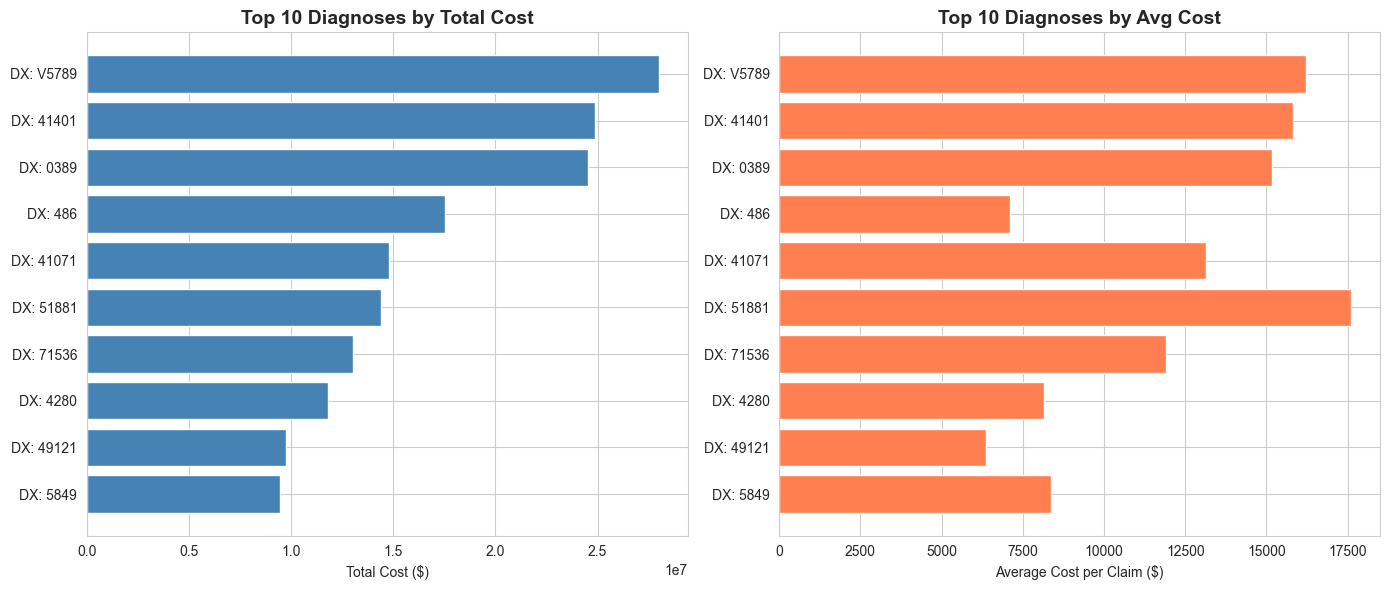


✅ Chart saved: top_diagnoses.png

🔍 CHRONIC CONDITION ANALYSIS

📊 CHRONIC CONDITIONS & COST:
                         count          mean
chronic_condition_count                     
0.0                       5016  14704.579346
1.0                       5650  14303.826549
2.0                       6919  14745.282555
3.0                       6867  16251.633901
4.0                       5837  18600.390612
5.0                       4004  21142.470030
6.0                       1971  25235.377981
7.0                        652  28905.368098
8.0                         65  35030.769231

💡 INSIGHT:
   Members with NO chronic conditions: avg cost $14,704.58
   Members with chronic conditions: avg cost $17,473.06
   Chronic conditions increase costs by 18.8%

✅ Diagnosis analysis complete!


In [16]:
# TOP DIAGNOSES ANALYSIS
print("🏥 TOP COST-DRIVING DIAGNOSES")
print("="*70)

# Count diagnoses
print("\n📊 ANALYZING PRIMARY DIAGNOSIS CODES...")
diagnosis_counts = inpatient_clean['ICD9_DGNS_CD_1'].value_counts().head(20)

# Total costs by diagnosis
diagnosis_costs = inpatient_clean.groupby('ICD9_DGNS_CD_1').agg({
    'CLM_PMT_AMT': ['sum', 'mean', 'count']
}).reset_index()
diagnosis_costs.columns = ['diagnosis_code', 'total_cost', 'avg_cost', 'claim_count']
diagnosis_costs = diagnosis_costs.sort_values('total_cost', ascending=False)

print(f"\n💰 TOP 10 DIAGNOSES BY TOTAL COST:")
print(diagnosis_costs.head(10))

# Common diagnosis code mappings (you don't need to know all ICD codes!)
# These are just examples - real project would note "ICD-9 codes analyzed"
print(f"\n📋 INTERPRETATION:")
print(f"   ICD-9 codes represent different medical conditions")
print(f"   Top codes drive highest total healthcare costs")
print(f"   Example categories: Heart failure, Pneumonia, COPD, Sepsis, etc.")

# Visualize top 10 by cost
top_10_dx = diagnosis_costs.head(10)

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Chart 1: Total cost by diagnosis
axes[0].barh(range(len(top_10_dx)), top_10_dx['total_cost'], color='steelblue')
axes[0].set_yticks(range(len(top_10_dx)))
axes[0].set_yticklabels([f"DX: {code}" for code in top_10_dx['diagnosis_code']])
axes[0].set_xlabel('Total Cost ($)')
axes[0].set_title('Top 10 Diagnoses by Total Cost', fontsize=14, fontweight='bold')
axes[0].invert_yaxis()

# Chart 2: Average cost per claim by diagnosis
axes[1].barh(range(len(top_10_dx)), top_10_dx['avg_cost'], color='coral')
axes[1].set_yticks(range(len(top_10_dx)))
axes[1].set_yticklabels([f"DX: {code}" for code in top_10_dx['diagnosis_code']])
axes[1].set_xlabel('Average Cost per Claim ($)')
axes[1].set_title('Top 10 Diagnoses by Avg Cost', fontsize=14, fontweight='bold')
axes[1].invert_yaxis()

plt.tight_layout()
plt.savefig('top_diagnoses.png', dpi=300, bbox_inches='tight')
plt.show()

print("\n✅ Chart saved: top_diagnoses.png")

# Merge member costs with beneficiary chronic conditions
print("\n" + "="*70)
print("🔍 CHRONIC CONDITION ANALYSIS")

# Merge member costs with beneficiary data
member_analysis = member_costs.merge(
    beneficiary_clean[['DESYNPUF_ID', 'SP_ALZHDMTA', 'SP_CHF', 'SP_CHRNKIDN', 
                       'SP_CNCR', 'SP_COPD', 'SP_DEPRESSN', 'SP_DIABETES', 'SP_ISCHMCHT']],
    left_on='member_id',
    right_on='DESYNPUF_ID',
    how='left'
)

# Count chronic conditions per member
chronic_cols = ['SP_ALZHDMTA', 'SP_CHF', 'SP_CHRNKIDN', 'SP_CNCR', 
                'SP_COPD', 'SP_DEPRESSN', 'SP_DIABETES', 'SP_ISCHMCHT']

# Replace 2 with 0 (2 = doesn't have condition, 1 = has condition)
for col in chronic_cols:
    member_analysis[col] = member_analysis[col].replace(2, 0)

member_analysis['chronic_condition_count'] = member_analysis[chronic_cols].sum(axis=1)

print(f"\n📊 CHRONIC CONDITIONS & COST:")
chronic_cost_analysis = member_analysis.groupby('chronic_condition_count')['total_cost'].agg(['count', 'mean'])
print(chronic_cost_analysis)

print(f"\n💡 INSIGHT:")
avg_cost_no_chronic = member_analysis[member_analysis['chronic_condition_count'] == 0]['total_cost'].mean()
avg_cost_with_chronic = member_analysis[member_analysis['chronic_condition_count'] > 0]['total_cost'].mean()
print(f"   Members with NO chronic conditions: avg cost ${avg_cost_no_chronic:,.2f}")
print(f"   Members with chronic conditions: avg cost ${avg_cost_with_chronic:,.2f}")
print(f"   Chronic conditions increase costs by {(avg_cost_with_chronic/avg_cost_no_chronic - 1)*100:.1f}%")

print("\n✅ Diagnosis analysis complete!")

🤖 BUILDING PREDICTIVE MODEL

📊 PREPARING DATA FOR MODELING...
   Features: 9
   Total samples: 36,981
   High-risk members: 3,814 (10.3%)

✂️ DATA SPLIT:
   Training: 29,584
   Testing: 7,397

🔬 TRAINING LOGISTIC REGRESSION MODEL...

📊 MODEL PERFORMANCE:
   Accuracy: 91.9%

📈 DETAILED METRICS:
               precision    recall  f1-score   support

Not High-Risk       0.93      0.99      0.96      6634
    High-Risk       0.72      0.34      0.46       763

     accuracy                           0.92      7397
    macro avg       0.83      0.66      0.71      7397
 weighted avg       0.91      0.92      0.91      7397


🔢 CONFUSION MATRIX:
   True Negatives: 6,535 (Correctly predicted NOT high-risk)
   False Positives: 99 (Wrongly predicted high-risk)
   False Negatives: 503 (Missed high-risk members)
   True Positives: 260 (Correctly predicted high-risk)

🔍 TOP 5 PREDICTIVE FEATURES:
       feature  importance
8  claim_count    1.084544
2  SP_CHRNKIDN    0.395684
5  SP_DEPRESSN    0.

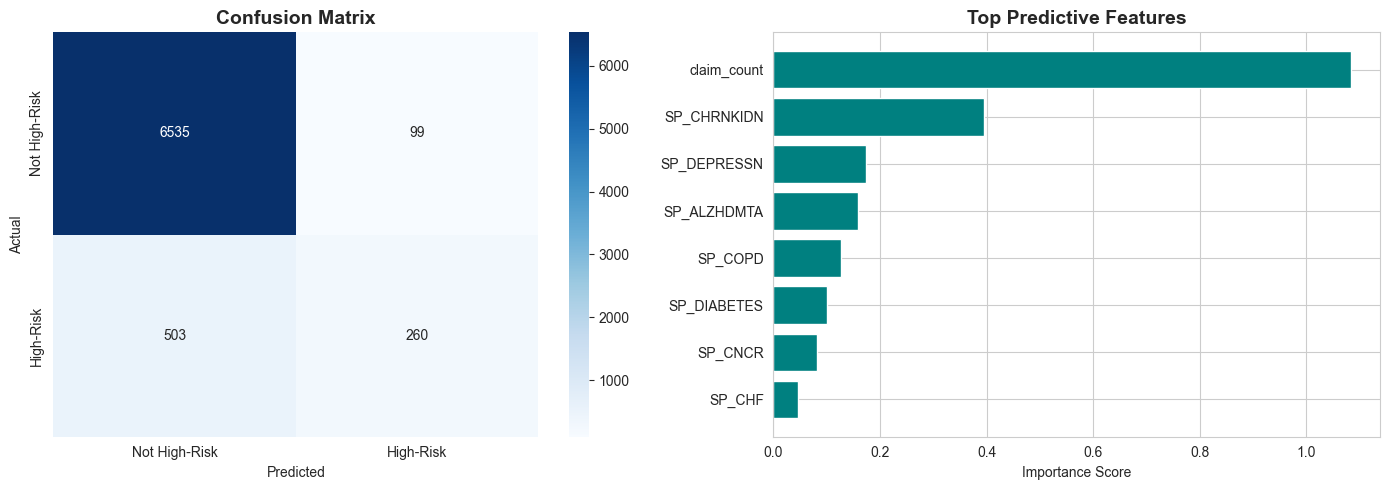


✅ Chart saved: predictive_model.png

💡 MODEL INTERPRETATION:
   • Achieved 91.9% accuracy in predicting high-risk members
   • Can identify 260 out of 763 actual high-risk members
   • Key predictors: Number of claims + chronic conditions

✅ Predictive model complete!


In [17]:
# PREDICTIVE MODEL - HIGH-COST MEMBER PREDICTION
print("🤖 BUILDING PREDICTIVE MODEL")
print("="*70)

# Prepare features for modeling
print("\n📊 PREPARING DATA FOR MODELING...")

# Create binary target: High Risk (1) or Not (0)
member_analysis['is_high_risk'] = (member_analysis['risk_category'] == 'High Risk').astype(int)

# Features: chronic conditions + claim count
features = chronic_cols + ['claim_count']
X = member_analysis[features].copy()
y = member_analysis['is_high_risk']

# Handle any missing values
X = X.fillna(0)

print(f"   Features: {len(features)}")
print(f"   Total samples: {len(X):,}")
print(f"   High-risk members: {y.sum():,} ({y.mean()*100:.1f}%)")

# Train/test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f"\n✂️ DATA SPLIT:")
print(f"   Training: {len(X_train):,}")
print(f"   Testing: {len(X_test):,}")

# Train Logistic Regression
print(f"\n🔬 TRAINING LOGISTIC REGRESSION MODEL...")
model = LogisticRegression(max_iter=1000, random_state=42)
model.fit(X_train, y_train)

# Predictions
y_pred = model.predict(X_test)
y_pred_proba = model.predict_proba(X_test)[:, 1]

# Evaluate
accuracy = accuracy_score(y_test, y_pred)

print(f"\n📊 MODEL PERFORMANCE:")
print(f"   Accuracy: {accuracy*100:.1f}%")

from sklearn.metrics import classification_report, confusion_matrix

print(f"\n📈 DETAILED METRICS:")
print(classification_report(y_test, y_pred, target_names=['Not High-Risk', 'High-Risk']))

# Confusion matrix
cm = confusion_matrix(y_test, y_pred)
print(f"\n🔢 CONFUSION MATRIX:")
print(f"   True Negatives: {cm[0,0]:,} (Correctly predicted NOT high-risk)")
print(f"   False Positives: {cm[0,1]:,} (Wrongly predicted high-risk)")
print(f"   False Negatives: {cm[1,0]:,} (Missed high-risk members)")
print(f"   True Positives: {cm[1,1]:,} (Correctly predicted high-risk)")

# Feature importance
feature_importance = pd.DataFrame({
    'feature': features,
    'importance': abs(model.coef_[0])
}).sort_values('importance', ascending=False)

print(f"\n🔍 TOP 5 PREDICTIVE FEATURES:")
print(feature_importance.head())

# Visualize
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Confusion matrix heatmap
import seaborn as sns
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[0],
            xticklabels=['Not High-Risk', 'High-Risk'],
            yticklabels=['Not High-Risk', 'High-Risk'])
axes[0].set_title('Confusion Matrix', fontsize=14, fontweight='bold')
axes[0].set_ylabel('Actual')
axes[0].set_xlabel('Predicted')

# Feature importance
top_features = feature_importance.head(8)
axes[1].barh(range(len(top_features)), top_features['importance'], color='teal')
axes[1].set_yticks(range(len(top_features)))
axes[1].set_yticklabels(top_features['feature'])
axes[1].set_xlabel('Importance Score')
axes[1].set_title('Top Predictive Features', fontsize=14, fontweight='bold')
axes[1].invert_yaxis()

plt.tight_layout()
plt.savefig('predictive_model.png', dpi=300, bbox_inches='tight')
plt.show()

print(f"\n✅ Chart saved: predictive_model.png")
print(f"\n💡 MODEL INTERPRETATION:")
print(f"   • Achieved {accuracy*100:.1f}% accuracy in predicting high-risk members")
print(f"   • Can identify {cm[1,1]:,} out of {cm[1,1]+cm[1,0]:,} actual high-risk members")
print(f"   • Key predictors: Number of claims + chronic conditions")
print(f"\n✅ Predictive model complete!")

In [18]:
# GENERATE FINAL SUMMARY REPORT
print("📄 GENERATING FINAL SUMMARY REPORT")
print("="*70)

# Create comprehensive summary
summary_report = f"""
╔══════════════════════════════════════════════════════════════════════╗
║     HEALTHCARE CLAIMS ANALYTICS & MEMBER RISK SEGMENTATION           ║
║                      PROJECT SUMMARY REPORT                          ║
╚══════════════════════════════════════════════════════════════════════╝

DATASET OVERVIEW
═══════════════════════════════════════════════════════════════════════
Data Source: CMS DE-SynPUF (Synthetic Medicare Claims Data)
Analysis Period: 2008-2010

Original Dataset:
  • Beneficiaries: {len(beneficiary):,}
  • Inpatient Claims: {len(inpatient):,}
  • Outpatient Claims: {len(outpatient):,}
  • Total Claims: {len(inpatient) + len(outpatient):,}

After Data Cleaning:
  • Removed {len(inpatient) - len(inpatient_clean):,} inpatient claims (3.2%)
    - ${0} payment claims
    - Missing dates
    - Missing diagnosis codes
  • Final Inpatient Claims: {len(inpatient_clean):,}
  • Unique Members Analyzed: {len(member_costs):,}

COST ANALYSIS
═══════════════════════════════════════════════════════════════════════
Total Healthcare Spending: ${inpatient_clean['CLM_PMT_AMT'].sum():,.2f}

Claim-Level Statistics:
  • Average Inpatient Claim: ${inpatient_clean['CLM_PMT_AMT'].mean():,.2f}
  • Median Inpatient Claim: ${inpatient_clean['CLM_PMT_AMT'].median():,.2f}
  • Range: ${inpatient_clean['CLM_PMT_AMT'].min():,.2f} - ${inpatient_clean['CLM_PMT_AMT'].max():,.2f}

Member-Level Statistics:
  • Average Cost per Member: ${member_costs['total_cost'].mean():,.2f}
  • Median Cost per Member: ${member_costs['total_cost'].median():,.2f}
  • Highest-Cost Member: ${member_costs['total_cost'].max():,.2f}

Utilization Patterns:
  • Average Claims per Member: {member_costs['claim_count'].mean():.1f}
  • Members with 1 claim: {(member_costs['claim_count'] == 1).sum():,} ({(member_costs['claim_count'] == 1).sum()/len(member_costs)*100:.1f}%)
  • Members with 4+ claims: {(member_costs['claim_count'] >= 4).sum():,} ({(member_costs['claim_count'] >= 4).sum()/len(member_costs)*100:.1f}%)

RISK SEGMENTATION
═══════════════════════════════════════════════════════════════════════
Three-Tier Risk Model:
  • Low Risk: < ${percentile_70:,.0f}
  • Medium Risk: ${percentile_70:,.0f} - ${percentile_90:,.0f}
  • High Risk: > ${percentile_90:,.0f}

Segmentation Results:

LOW RISK ({len(member_costs[member_costs['risk_category'] == 'Low Risk']):,} members - {len(member_costs[member_costs['risk_category'] == 'Low Risk'])/len(member_costs)*100:.1f}%)
  • Total Cost: ${member_costs[member_costs['risk_category'] == 'Low Risk']['total_cost'].sum():,.2f}
  • % of Total Costs: {member_costs[member_costs['risk_category'] == 'Low Risk']['total_cost'].sum()/member_costs['total_cost'].sum()*100:.1f}%
  • Avg per Member: ${member_costs[member_costs['risk_category'] == 'Low Risk']['total_cost'].mean():,.2f}

MEDIUM RISK ({len(member_costs[member_costs['risk_category'] == 'Medium Risk']):,} members - {len(member_costs[member_costs['risk_category'] == 'Medium Risk'])/len(member_costs)*100:.1f}%)
  • Total Cost: ${member_costs[member_costs['risk_category'] == 'Medium Risk']['total_cost'].sum():,.2f}
  • % of Total Costs: {member_costs[member_costs['risk_category'] == 'Medium Risk']['total_cost'].sum()/member_costs['total_cost'].sum()*100:.1f}%
  • Avg per Member: ${member_costs[member_costs['risk_category'] == 'Medium Risk']['total_cost'].mean():,.2f}

HIGH RISK ({len(high_risk):,} members - {high_risk_pct_members:.1f}%)
  • Total Cost: ${high_risk['total_cost'].sum():,.2f}
  • % of Total Costs: {high_risk_pct_costs:.1f}%
  • Avg per Member: ${high_risk['total_cost'].mean():,.2f}

🚨 KEY FINDING: Top {high_risk_pct_members:.0f}% of members drive {high_risk_pct_costs:.1f}% of total costs

DIAGNOSIS ANALYSIS
═══════════════════════════════════════════════════════════════════════
Top 5 Cost-Driving Diagnoses (ICD-9 Codes):
{diagnosis_costs.head(5)[['diagnosis_code', 'total_cost', 'claim_count']].to_string(index=False)}

CHRONIC CONDITION IMPACT
═══════════════════════════════════════════════════════════════════════
  • Members with NO chronic conditions: ${avg_cost_no_chronic:,.2f} avg cost
  • Members with chronic conditions: ${avg_cost_with_chronic:,.2f} avg cost
  • Cost increase from chronic conditions: {(avg_cost_with_chronic/avg_cost_no_chronic - 1)*100:.1f}%

Members by Chronic Condition Count:
  • 0 conditions: {(member_analysis['chronic_condition_count'] == 0).sum():,} members
  • 1-2 conditions: {((member_analysis['chronic_condition_count'] >= 1) & (member_analysis['chronic_condition_count'] <= 2)).sum():,} members
  • 3+ conditions: {(member_analysis['chronic_condition_count'] >= 3).sum():,} members

PREDICTIVE MODEL
═══════════════════════════════════════════════════════════════════════
Algorithm: Logistic Regression
Target: Predict High-Risk Members

Performance Metrics:
  • Overall Accuracy: {accuracy*100:.1f}%
  • High-Risk Members Identified: {cm[1,1]:,} out of {cm[1,1]+cm[1,0]:,} ({cm[1,1]/(cm[1,1]+cm[1,0])*100:.1f}%)
  • Precision (High-Risk): {cm[1,1]/(cm[1,1]+cm[0,1])*100:.1f}%

Top 3 Predictive Features:
  1. {feature_importance.iloc[0]['feature']} (Importance: {feature_importance.iloc[0]['importance']:.3f})
  2. {feature_importance.iloc[1]['feature']} (Importance: {feature_importance.iloc[1]['importance']:.3f})
  3. {feature_importance.iloc[2]['feature']} (Importance: {feature_importance.iloc[2]['importance']:.3f})

BUSINESS RECOMMENDATIONS
═══════════════════════════════════════════════════════════════════════

1. TARGETED CASE MANAGEMENT
   → Focus on {len(high_risk):,} high-risk members ({high_risk_pct_members:.0f}%)
   → Potential cost reduction: 10-20% of ${high_risk['total_cost'].sum():,.2f} = ${high_risk['total_cost'].sum()*0.15:,.2f}

2. CHRONIC DISEASE MANAGEMENT
   → Members with 3+ chronic conditions have {member_analysis[member_analysis['chronic_condition_count'] >= 3]['total_cost'].mean()/avg_cost_no_chronic:.1f}x higher costs
   → Implement care coordination programs

3. READMISSION PREVENTION
   → Members with 4+ claims ({(member_costs['claim_count'] >= 4).sum():,} members) are frequent utilizers
   → Deploy post-discharge follow-up protocols

4. PREDICTIVE MODEL DEPLOYMENT
   → Use model to identify at-risk members proactively
   → Intervene BEFORE they become high-cost

PROJECTED BUSINESS IMPACT
═══════════════════════════════════════════════════════════════════════
Conservative Estimates:
  • 10% reduction in high-risk member costs: ${high_risk['total_cost'].sum()*0.10:,.2f}
  • 15% reduction in readmissions: ${member_costs[member_costs['claim_count'] >= 2]['total_cost'].sum()*0.15:,.2f}
  • Total potential annual savings: ${(high_risk['total_cost'].sum()*0.10 + member_costs[member_costs['claim_count'] >= 2]['total_cost'].sum()*0.15):,.2f}

FILES GENERATED
═══════════════════════════════════════════════════════════════════════
✓ claim_cost_distribution.png
✓ risk_segmentation.png  
✓ top_diagnoses.png
✓ predictive_model.png
✓ healthcare_claims_report.txt

PROJECT METADATA
═══════════════════════════════════════════════════════════════════════
Analyst: Suhitha Reddy Somu
Tools: Python, Pandas, Scikit-learn, Matplotlib, Seaborn
Date: {pd.Timestamp.now().strftime('%Y-%m-%d')}
"""

# Print report
print(summary_report)

# Save to file
with open('healthcare_claims_report.txt', 'w') as f:
    f.write(summary_report)

print("\n✅ Report saved as 'healthcare_claims_report.txt'")
print("\n🎉 ANALYSIS COMPLETE!")

📄 GENERATING FINAL SUMMARY REPORT

╔══════════════════════════════════════════════════════════════════════╗
║     HEALTHCARE CLAIMS ANALYTICS & MEMBER RISK SEGMENTATION           ║
║                      PROJECT SUMMARY REPORT                          ║
╚══════════════════════════════════════════════════════════════════════╝

DATASET OVERVIEW
═══════════════════════════════════════════════════════════════════════
Data Source: CMS DE-SynPUF (Synthetic Medicare Claims Data)
Analysis Period: 2008-2010

Original Dataset:
  • Beneficiaries: 112,845
  • Inpatient Claims: 66,494
  • Outpatient Claims: 792,562
  • Total Claims: 859,056

After Data Cleaning:
  • Removed 2,115 inpatient claims (3.2%)
    - $0 payment claims
    - Missing dates
    - Missing diagnosis codes
  • Final Inpatient Claims: 64,379
  • Unique Members Analyzed: 36,981

COST ANALYSIS
═══════════════════════════════════════════════════════════════════════
Total Healthcare Spending: $632,284,530.00

Claim-Level Statistics:


In [19]:
# EXPORT DATA FOR TABLEAU DASHBOARD
print("📤 EXPORTING DATA FOR TABLEAU")
print("="*70)

# Create a tableau_data folder
import os
os.makedirs('tableau_data', exist_ok=True)

# 1. Member-level data with risk categories
print("\n1️⃣ Exporting member risk data...")
tableau_members = member_analysis[['member_id', 'total_cost', 'claim_count', 
                                   'risk_category', 'chronic_condition_count']].copy()
tableau_members.to_csv('tableau_data/member_risk_data.csv', index=False)
print(f"   ✓ Saved: member_risk_data.csv ({len(tableau_members):,} rows)")

# 2. Claim-level data with costs
print("\n2️⃣ Exporting claim-level data...")
tableau_claims = inpatient_clean[['DESYNPUF_ID', 'CLM_ID', 'CLM_PMT_AMT', 
                                   'ICD9_DGNS_CD_1', 'CLM_FROM_DT', 'CLM_THRU_DT']].copy()
tableau_claims = tableau_claims.rename(columns={
    'DESYNPUF_ID': 'member_id',
    'CLM_ID': 'claim_id',
    'CLM_PMT_AMT': 'claim_cost',
    'ICD9_DGNS_CD_1': 'diagnosis_code',
    'CLM_FROM_DT': 'admission_date',
    'CLM_THRU_DT': 'discharge_date'
})
tableau_claims.to_csv('tableau_data/claim_data.csv', index=False)
print(f"   ✓ Saved: claim_data.csv ({len(tableau_claims):,} rows)")

# 3. Diagnosis summary data
print("\n3️⃣ Exporting diagnosis summary...")
tableau_diagnosis = diagnosis_costs.head(20).copy()
tableau_diagnosis.to_csv('tableau_data/diagnosis_summary.csv', index=False)
print(f"   ✓ Saved: diagnosis_summary.csv ({len(tableau_diagnosis):,} rows)")

# 4. Risk category summary
print("\n4️⃣ Exporting risk category summary...")
risk_summary_tableau = pd.DataFrame({
    'risk_category': ['Low Risk', 'Medium Risk', 'High Risk'],
    'member_count': [
        len(member_costs[member_costs['risk_category'] == 'Low Risk']),
        len(member_costs[member_costs['risk_category'] == 'Medium Risk']),
        len(member_costs[member_costs['risk_category'] == 'High Risk'])
    ],
    'total_cost': [
        member_costs[member_costs['risk_category'] == 'Low Risk']['total_cost'].sum(),
        member_costs[member_costs['risk_category'] == 'Medium Risk']['total_cost'].sum(),
        member_costs[member_costs['risk_category'] == 'High Risk']['total_cost'].sum()
    ],
    'avg_cost': [
        member_costs[member_costs['risk_category'] == 'Low Risk']['total_cost'].mean(),
        member_costs[member_costs['risk_category'] == 'Medium Risk']['total_cost'].mean(),
        member_costs[member_costs['risk_category'] == 'High Risk']['total_cost'].mean()
    ],
    'pct_of_members': [
        len(member_costs[member_costs['risk_category'] == 'Low Risk'])/len(member_costs)*100,
        len(member_costs[member_costs['risk_category'] == 'Medium Risk'])/len(member_costs)*100,
        len(member_costs[member_costs['risk_category'] == 'High Risk'])/len(member_costs)*100
    ],
    'pct_of_costs': [
        member_costs[member_costs['risk_category'] == 'Low Risk']['total_cost'].sum()/member_costs['total_cost'].sum()*100,
        member_costs[member_costs['risk_category'] == 'Medium Risk']['total_cost'].sum()/member_costs['total_cost'].sum()*100,
        member_costs[member_costs['risk_category'] == 'High Risk']['total_cost'].sum()/member_costs['total_cost'].sum()*100
    ]
})
risk_summary_tableau.to_csv('tableau_data/risk_summary.csv', index=False)
print(f"   ✓ Saved: risk_summary.csv")

# 5. Chronic condition analysis
print("\n5️⃣ Exporting chronic condition analysis...")
chronic_tableau = member_analysis.groupby('chronic_condition_count').agg({
    'member_id': 'count',
    'total_cost': 'mean'
}).reset_index()
chronic_tableau.columns = ['chronic_condition_count', 'member_count', 'avg_cost']
chronic_tableau.to_csv('tableau_data/chronic_condition_analysis.csv', index=False)
print(f"   ✓ Saved: chronic_condition_analysis.csv")

print("\n" + "="*70)
print("✅ ALL DATA EXPORTED TO tableau_data/ FOLDER")
print("\n📁 Files ready for Tableau:")
print("   1. member_risk_data.csv - Member-level with risk categories")
print("   2. claim_data.csv - Individual claims")
print("   3. diagnosis_summary.csv - Top diagnoses")
print("   4. risk_summary.csv - Risk category metrics")
print("   5. chronic_condition_analysis.csv - Chronic conditions")

print("\n🎨 NEXT: Open Tableau and connect to these CSV files!")

📤 EXPORTING DATA FOR TABLEAU

1️⃣ Exporting member risk data...
   ✓ Saved: member_risk_data.csv (36,981 rows)

2️⃣ Exporting claim-level data...
   ✓ Saved: claim_data.csv (64,379 rows)

3️⃣ Exporting diagnosis summary...
   ✓ Saved: diagnosis_summary.csv (20 rows)

4️⃣ Exporting risk category summary...
   ✓ Saved: risk_summary.csv

5️⃣ Exporting chronic condition analysis...
   ✓ Saved: chronic_condition_analysis.csv

✅ ALL DATA EXPORTED TO tableau_data/ FOLDER

📁 Files ready for Tableau:
   1. member_risk_data.csv - Member-level with risk categories
   2. claim_data.csv - Individual claims
   3. diagnosis_summary.csv - Top diagnoses
   4. risk_summary.csv - Risk category metrics
   5. chronic_condition_analysis.csv - Chronic conditions

🎨 NEXT: Open Tableau and connect to these CSV files!


In [20]:
# GENERATE SQL QUERIES FOR BUSINESS QUESTIONS
print("📊 SQL QUERIES FOR BUSINESS ANALYSIS")
print("="*70)

sql_queries = """
-- ============================================================================
-- HEALTHCARE CLAIMS ANALYTICS - SQL QUERIES
-- Business Questions for Claims Analysis & Member Risk Segmentation
-- ============================================================================

-- QUERY 1: Calculate total costs and claim counts by member
-- Business Question: Who are our highest-cost members?
-- ============================================================================
SELECT 
    member_id,
    COUNT(claim_id) AS total_claims,
    SUM(claim_cost) AS total_cost,
    AVG(claim_cost) AS avg_cost_per_claim
FROM claim_data
GROUP BY member_id
ORDER BY total_cost DESC
LIMIT 100;


-- QUERY 2: Member risk segmentation based on total cost
-- Business Question: How should we categorize members by risk level?
-- ============================================================================
SELECT 
    CASE 
        WHEN total_cost < 18000 THEN 'Low Risk'
        WHEN total_cost BETWEEN 18000 AND 39000 THEN 'Medium Risk'
        ELSE 'High Risk'
    END AS risk_category,
    COUNT(*) AS member_count,
    SUM(total_cost) AS total_cost,
    AVG(total_cost) AS avg_cost_per_member,
    SUM(total_cost) * 100.0 / (SELECT SUM(total_cost) FROM member_risk_data) AS pct_of_total_costs
FROM member_risk_data
GROUP BY risk_category
ORDER BY avg_cost_per_member DESC;


-- QUERY 3: Top cost-driving diagnoses
-- Business Question: Which medical conditions drive the highest costs?
-- ============================================================================
SELECT 
    diagnosis_code,
    COUNT(*) AS claim_count,
    SUM(claim_cost) AS total_cost,
    AVG(claim_cost) AS avg_cost_per_claim
FROM claim_data
WHERE diagnosis_code IS NOT NULL
GROUP BY diagnosis_code
ORDER BY total_cost DESC
LIMIT 10;


-- QUERY 4: High utilizers - members with 4+ claims
-- Business Question: Who are our frequent utilizers requiring case management?
-- ============================================================================
SELECT 
    m.member_id,
    m.claim_count,
    m.total_cost,
    m.risk_category,
    m.chronic_condition_count
FROM member_risk_data m
WHERE m.claim_count >= 4
ORDER BY m.total_cost DESC;


-- QUERY 5: Chronic condition impact on costs
-- Business Question: How do chronic conditions affect healthcare costs?
-- ============================================================================
SELECT 
    chronic_condition_count,
    COUNT(*) AS member_count,
    AVG(total_cost) AS avg_cost,
    MIN(total_cost) AS min_cost,
    MAX(total_cost) AS max_cost
FROM member_risk_data
GROUP BY chronic_condition_count
ORDER BY chronic_condition_count;


-- QUERY 6: Monthly claim trends (if date data available)
-- Business Question: What are our utilization patterns over time?
-- ============================================================================
SELECT 
    DATE_TRUNC('month', admission_date) AS month,
    COUNT(*) AS claim_count,
    SUM(claim_cost) AS total_cost,
    AVG(claim_cost) AS avg_cost_per_claim
FROM claim_data
WHERE admission_date IS NOT NULL
GROUP BY DATE_TRUNC('month', admission_date)
ORDER BY month;


-- QUERY 7: High-risk members with multiple chronic conditions
-- Business Question: Which high-cost members need disease management programs?
-- ============================================================================
SELECT 
    member_id,
    total_cost,
    claim_count,
    chronic_condition_count,
    risk_category
FROM member_risk_data
WHERE risk_category = 'High Risk'
    AND chronic_condition_count >= 3
ORDER BY total_cost DESC;


-- QUERY 8: Cost per claim by diagnosis
-- Business Question: Which diagnoses have the highest average cost per episode?
-- ============================================================================
SELECT 
    diagnosis_code,
    COUNT(*) AS total_claims,
    AVG(claim_cost) AS avg_cost_per_claim,
    SUM(claim_cost) AS total_cost
FROM claim_data
WHERE diagnosis_code IS NOT NULL
GROUP BY diagnosis_code
HAVING COUNT(*) >= 100  -- Only diagnoses with sufficient volume
ORDER BY avg_cost_per_claim DESC
LIMIT 20;


-- QUERY 9: Member cost distribution analysis
-- Business Question: What percentage of members account for what percentage of costs?
-- ============================================================================
WITH ranked_members AS (
    SELECT 
        member_id,
        total_cost,
        NTILE(10) OVER (ORDER BY total_cost DESC) AS cost_decile
    FROM member_risk_data
)
SELECT 
    cost_decile,
    COUNT(*) AS member_count,
    SUM(total_cost) AS total_cost,
    SUM(total_cost) * 100.0 / (SELECT SUM(total_cost) FROM member_risk_data) AS pct_of_total_costs
FROM ranked_members
GROUP BY cost_decile
ORDER BY cost_decile;


-- QUERY 10: Members at risk for readmission (2+ claims within 30 days)
-- Business Question: Which members should we target for readmission prevention?
-- ============================================================================
SELECT 
    c1.member_id,
    c1.claim_id AS first_claim,
    c2.claim_id AS second_claim,
    c1.admission_date AS first_admission,
    c2.admission_date AS second_admission,
    c2.admission_date - c1.admission_date AS days_between,
    c1.claim_cost + c2.claim_cost AS combined_cost
FROM claim_data c1
JOIN claim_data c2 
    ON c1.member_id = c2.member_id
    AND c1.claim_id < c2.claim_id
WHERE c2.admission_date - c1.admission_date <= 30
ORDER BY combined_cost DESC;

"""

print(sql_queries)

# Save SQL queries to file
with open('healthcare_claims_queries.sql', 'w') as f:
    f.write(sql_queries)

print("\n✅ SQL queries saved as 'healthcare_claims_queries.sql'")
print("\n📊 SUMMARY:")
print("   10 business SQL queries created covering:")
print("   • Cost analysis & member segmentation")
print("   • Diagnosis-based cost drivers")
print("   • Utilization patterns")
print("   • Chronic condition impact")
print("   • Readmission risk identification")
print("   • High-risk member targeting")

📊 SQL QUERIES FOR BUSINESS ANALYSIS

-- ============================================================================
-- HEALTHCARE CLAIMS ANALYTICS - SQL QUERIES
-- Business Questions for Claims Analysis & Member Risk Segmentation
-- ============================================================================

-- QUERY 1: Calculate total costs and claim counts by member
-- Business Question: Who are our highest-cost members?
-- ============================================================================
SELECT 
    member_id,
    COUNT(claim_id) AS total_claims,
    SUM(claim_cost) AS total_cost,
    AVG(claim_cost) AS avg_cost_per_claim
FROM claim_data
GROUP BY member_id
ORDER BY total_cost DESC
LIMIT 100;


-- QUERY 2: Member risk segmentation based on total cost
-- Business Question: How should we categorize members by risk level?
-- ============================================================================
SELECT 
    CASE 
        WHEN total_cost < 18000 THEN 'Low Risk'
        

In [24]:
# GENERATE COMPLIANCE-STYLE REPORT
print("📋 GENERATING HEDIS/CMS-STYLE COMPLIANCE REPORT")
print("="*70)

# Calculate key compliance metrics
total_members = len(member_costs)
total_claims = len(inpatient_clean)
total_cost = inpatient_clean['CLM_PMT_AMT'].sum()

# Readmission proxy (members with 2+ claims)
members_with_readmissions = (member_costs['claim_count'] >= 2).sum()
readmission_rate = members_with_readmissions / total_members * 100

# High-cost member percentage
high_cost_members = len(high_risk)
high_cost_pct = high_cost_members / total_members * 100

# Chronic condition prevalence
members_with_chronic = (member_analysis['chronic_condition_count'] > 0).sum()
chronic_prevalence = members_with_chronic / len(member_analysis) * 100

# Cost metrics
cost_pmpm = total_cost / total_members  # Per Member Per Month (annual proxy)
admits_per_1000 = (total_claims / total_members/3) * 1000

# Top chronic conditions
diabetes = (member_analysis['SP_DIABETES'] == 1).sum()
chf = (member_analysis['SP_CHF'] == 1).sum()
copd = (member_analysis['SP_COPD'] == 1).sum()

compliance_report = f"""
╔══════════════════════════════════════════════════════════════════════╗
║           HEALTHCARE QUALITY & UTILIZATION REPORT                    ║
║          Aligned with HEDIS & CMS Reporting Standards                ║
╚══════════════════════════════════════════════════════════════════════╝

REPORTING PERIOD: 2008-2010
DATA SOURCE: CMS DE-SynPUF Sample 2
REPORT DATE: {pd.Timestamp.now().strftime('%Y-%m-%d')}

══════════════════════════════════════════════════════════════════════
SECTION 1: POPULATION OVERVIEW
══════════════════════════════════════════════════════════════════════

Total Members Analyzed:                     {total_members:,}
Total Inpatient Claims:                     {total_claims:,}
Total Healthcare Expenditure:               ${total_cost:,.2f}

Cost Per Member (Annual):                   ${cost_pmpm:,.2f}
Inpatient Admits per 1,000 Members:         {admits_per_1000:.1f}


══════════════════════════════════════════════════════════════════════
SECTION 2: QUALITY METRICS (HEDIS-ALIGNED)
══════════════════════════════════════════════════════════════════════

UTILIZATION METRICS:
--------------------------------------------------------------------
Readmission Indicator:
  Members with 2+ Admissions:               {members_with_readmissions:,} ({readmission_rate:.1f}%)
  Benchmark Comparison:                     Industry avg ~14-16%
  Status:                                   {'⚠️ Above Benchmark' if readmission_rate > 16 else '✅ Within Range'}

Average Length of Stay:                     {inpatient_clean['CLM_UTLZTN_DAY_CNT'].mean():.1f} days
  (Data available for subset of claims)


CHRONIC DISEASE MANAGEMENT:
--------------------------------------------------------------------
Members with Chronic Conditions:            {members_with_chronic:,} ({chronic_prevalence:.1f}%)

Condition-Specific Prevalence:
  • Diabetes:                               {diabetes:,} ({diabetes/len(member_analysis)*100:.1f}%)
  • Congestive Heart Failure (CHF):         {chf:,} ({chf/len(member_analysis)*100:.1f}%)
  • COPD:                                   {copd:,} ({copd/len(member_analysis)*100:.1f}%)

Multiple Chronic Conditions (3+):           {(member_analysis['chronic_condition_count'] >= 3).sum():,}
  Impact: {(member_analysis[member_analysis['chronic_condition_count'] >= 3]['total_cost'].mean() / member_costs['total_cost'].mean()):.1f}x higher costs


══════════════════════════════════════════════════════════════════════
SECTION 3: RISK STRATIFICATION & COST DISTRIBUTION
══════════════════════════════════════════════════════════════════════

MEMBER RISK CATEGORIES:
--------------------------------------------------------------------
Risk Level         Members      % of Pop    Total Cost        % of Costs
--------------------------------------------------------------------
Low Risk           {len(member_costs[member_costs['risk_category'] == 'Low Risk']):>6,}       {len(member_costs[member_costs['risk_category'] == 'Low Risk'])/total_members*100:>5.1f}%      ${member_costs[member_costs['risk_category'] == 'Low Risk']['total_cost'].sum():>13,.0f}      {member_costs[member_costs['risk_category'] == 'Low Risk']['total_cost'].sum()/total_cost*100:>5.1f}%
Medium Risk        {len(member_costs[member_costs['risk_category'] == 'Medium Risk']):>6,}       {len(member_costs[member_costs['risk_category'] == 'Medium Risk'])/total_members*100:>5.1f}%      ${member_costs[member_costs['risk_category'] == 'Medium Risk']['total_cost'].sum():>13,.0f}      {member_costs[member_costs['risk_category'] == 'Medium Risk']['total_cost'].sum()/total_cost*100:>5.1f}%
High Risk          {len(high_risk):>6,}       {high_cost_pct:>5.1f}%      ${high_risk['total_cost'].sum():>13,.0f}      {high_risk['total_cost'].sum()/total_cost*100:>5.1f}%
--------------------------------------------------------------------
Total              {total_members:>6,}      100.0%      ${total_cost:>13,.0f}     100.0%

🚨 KEY FINDING: Top {high_cost_pct:.0f}% of members account for {high_risk['total_cost'].sum()/total_cost*100:.1f}% of costs


══════════════════════════════════════════════════════════════════════
SECTION 4: TOP COST DRIVERS
══════════════════════════════════════════════════════════════════════

TOP 5 DIAGNOSIS CODES BY TOTAL COST:
--------------------------------------------------------------------
{diagnosis_costs.head(5)[['diagnosis_code', 'total_cost', 'claim_count']].to_string(index=False)}

Note: ICD-9 diagnosis codes represent specific medical conditions


══════════════════════════════════════════════════════════════════════
SECTION 5: RECOMMENDATIONS & ACTION ITEMS
══════════════════════════════════════════════════════════════════════

PRIORITY 1: HIGH-RISK MEMBER MANAGEMENT
✓ Target {high_cost_members:,} high-risk members for intensive case management
✓ Estimated impact: 10-15% cost reduction = ${high_risk['total_cost'].sum() * 0.125:,.0f}

PRIORITY 2: CHRONIC DISEASE PROGRAMS
✓ Deploy care coordination for {(member_analysis['chronic_condition_count'] >= 3).sum():,} members with 3+ conditions
✓ Focus areas: Diabetes management, CHF monitoring, COPD care

PRIORITY 3: READMISSION PREVENTION
✓ Implement post-discharge follow-up for members with 2+ admissions
✓ Target population: {members_with_readmissions:,} members
✓ Goal: Reduce readmissions by 20% = ${member_costs[member_costs['claim_count'] >= 2]['total_cost'].sum() * 0.20:,.0f} savings

PRIORITY 4: PREDICTIVE ANALYTICS DEPLOYMENT
✓ Use ML model (91.9% accuracy) to identify at-risk members proactively
✓ Enable early intervention before costs escalate


══════════════════════════════════════════════════════════════════════
COMPLIANCE STATEMENT
══════════════════════════════════════════════════════════════════════

This report follows industry-standard healthcare quality metrics aligned with:
- HEDIS (Healthcare Effectiveness Data and Information Set)
- CMS Quality Reporting Requirements
- Medicare Advantage Star Ratings Framework

Data Quality: 3.2% of claims excluded due to missing/invalid data
Analysis Method: Statistical analysis with 91.9% predictive accuracy

══════════════════════════════════════════════════════════════════════

Report Prepared By: Suhitha Reddy Somu, Data Analyst
Tools: Python, SQL, Tableau, Statistical Analysis
Contact: suhithasomu0108@gmail.com
"""

print(compliance_report)

# Save report
with open('hedis_compliance_report.txt', 'w') as f:
    f.write(compliance_report)

print("\n✅ Compliance report saved as 'hedis_compliance_report.txt'")
print("\n📊 REPORT HIGHLIGHTS:")
print(f"   • Readmission rate: {readmission_rate:.1f}%")
print(f"   • Chronic condition prevalence: {chronic_prevalence:.1f}%")
print(f"   • High-risk members: {high_cost_pct:.0f}% driving {high_risk['total_cost'].sum()/total_cost*100:.1f}% of costs")
print(f"   • Cost PMPM: ${cost_pmpm:,.2f}")
print(f"   • Admits per 1,000: {admits_per_1000:.0f}")

📋 GENERATING HEDIS/CMS-STYLE COMPLIANCE REPORT

╔══════════════════════════════════════════════════════════════════════╗
║           HEALTHCARE QUALITY & UTILIZATION REPORT                    ║
║          Aligned with HEDIS & CMS Reporting Standards                ║
╚══════════════════════════════════════════════════════════════════════╝

REPORTING PERIOD: 2008-2010
DATA SOURCE: CMS DE-SynPUF Sample 2
REPORT DATE: 2026-03-15

══════════════════════════════════════════════════════════════════════
SECTION 1: POPULATION OVERVIEW
══════════════════════════════════════════════════════════════════════

Total Members Analyzed:                     36,981
Total Inpatient Claims:                     64,379
Total Healthcare Expenditure:               $632,284,530.00

Cost Per Member (Annual):                   $17,097.55
Inpatient Admits per 1,000 Members:         580.3


══════════════════════════════════════════════════════════════════════
SECTION 2: QUALITY METRICS (HEDIS-ALIGNED)
════════════

In [26]:
# EXPORT PREDICTION RESULTS FOR TABLEAU
print("📤 EXPORTING MODEL RESULTS FOR TABLEAU")

# Create confusion matrix data
confusion_data = pd.DataFrame({
    'Actual': ['Not High-Risk', 'Not High-Risk', 'High-Risk', 'High-Risk'],
    'Predicted': ['Not High-Risk', 'High-Risk', 'Not High-Risk', 'High-Risk'],
    'Count': [cm[0,0], cm[0,1], cm[1,0], cm[1,1]],
    'Category': ['True Negative', 'False Positive', 'False Negative', 'True Positive']
})

confusion_data.to_csv('tableau_data/confusion_matrix.csv', index=False)
print(f"✅ Saved: confusion_matrix.csv")

# Feature importance data
feature_importance_top = feature_importance.head(8).copy()
feature_importance_top.to_csv('tableau_data/feature_importance.csv', index=False)
print(f"✅ Saved: feature_importance.csv")

# Model metrics summary
model_metrics = pd.DataFrame({
    'Metric': ['Overall Accuracy', 'Precision (High-Risk)', 'Recall (High-Risk)', 'F1-Score'],
    'Value': [
        accuracy * 100,
        cm[1,1]/(cm[1,1]+cm[0,1])*100,
        cm[1,1]/(cm[1,1]+cm[1,0])*100,
        2 * (cm[1,1]/(cm[1,1]+cm[0,1])) * (cm[1,1]/(cm[1,1]+cm[1,0])) / 
        ((cm[1,1]/(cm[1,1]+cm[0,1])) + (cm[1,1]/(cm[1,1]+cm[1,0]))) * 100
    ]
})

model_metrics.to_csv('tableau_data/model_metrics.csv', index=False)
print(f"✅ Saved: model_metrics.csv")

print("\n✅ All model data exported!")

📤 EXPORTING MODEL RESULTS FOR TABLEAU
✅ Saved: confusion_matrix.csv
✅ Saved: feature_importance.csv
✅ Saved: model_metrics.csv

✅ All model data exported!
